# Craindo uma rede neural do zero

Nesse priojeto, construiremos uma rede neural utilizando o problema de minist


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import torch 
import torch.nn.functional as F
import torchvision
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [34]:
transform = transforms.ToTensor()

trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

valset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

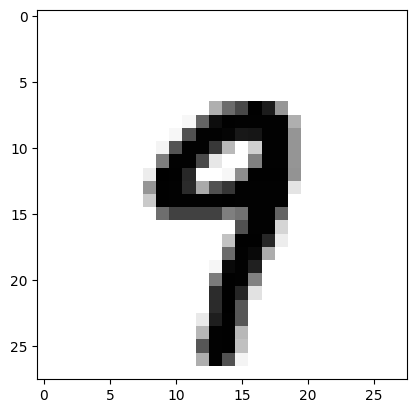

In [35]:
dataiter = iter(trainloader)
images, etiquetas = next(dataiter)    
plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')

In [36]:
print(images[0].shape) # para ver o formato da imagem, as dimensões so tensor 
print(etiquetas[0].shape) # para ver a etiqueta associada a imagem


torch.Size([1, 28, 28])
torch.Size([])


In [37]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.linear1 = nn.Linear(28*28, 128) # camada de entrada, 784 neurônios que se ligam a 128 neurônios na camada oculta 
        self.linear2 = nn.Linear(128, 64) # camada interna 1, 128 neurônios que se ligam a 64 neurônios na camada oculta 2
        self.linear3 = nn.Linear(64, 10) # camada interna 2, 64 neurônios que se ligam a 10 neurônios na camada de saída
        # para a camada de saída não é necessario definir nada pois só precisamos pegar o output da camada interna 2
        
    def forward(self, x):
        x = F.relu(self.linear1(x)) # função de ativação da camada de entrada para a camada interna 1
        x = F.relu(self.linear2(x)) # função de ativação da camada interna 1 para a camada interna 2
        x = self.linear3(x) # saída da camada interna 2 para a camada de saída, nesse caso f(x) = x
        return F.log_softmax(x, dim=1) # dados utilizados para calcular a perda com a função NLLLoss

In [38]:
def treino(modelo, trainloader, device):
    otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5) # define a politica de atualização dos pesos e das bias
    inicio = time()

    criterio = nn.NLLLoss()
    EPOCHS = 10
    modelo.train()
    
    for epoch in range(EPOCHS):
        perda_acumulada = 0 # inicializa a perda acumulada para a época
        
        for imagens, etiquetas in trainloader:

            imagens = imagens.view(imagens.shape[0], -1) # converte as imagens para vetores de 784 elementos
            otimizador.zero_grad()

            output = modelo(imagens.to(device))
            perda_instantanea = criterio(output, etiquetas.to(device))

            perda_instantanea.backward()
            otimizador.step() # atualizando os pesos e as bias
            perda_acumulada += perda_instantanea.item()
        else:
            print("Epoch {} - Perda: {:.4f}".format(epoch+1, perda_acumulada/len(trainloader)))
    print("\nTempo de Treinamento (em minutos =", (time() - inicio)/60)

#        modelo.eval()
#        with torch.no_grad():
#            for imagens, etiquetas in valloader:
#                imagens = imagens.view(imagens.shape[0], -1)
#                output = modelo(imagens.to(device))
#                perda = criterio(output, etiquetas.to(device))
#                perda_validação += perda.item()
#        
#        fim = time()
#        print(f'Época {epoch+1}/{EPOCHS}.. '
#              f'Tempo: {fim - inicio:.2f} segundos.. '
#              f'Perda Treino: {perda_acumulada/len(trainloader):.3f}.. '
#              f'Perda Validação: {perda_validação/len(valloader):.3f}')
        
        

In [39]:
def validacao(modelo, valloader, device):
    conta_corretas, conta_todas = 0, 0
    for imagens, etiquetas in valloader:
        for i in range(len(etiquetas)):
            img = imagens[i].view(1, 784)
            with torch.no_grad():
                logps = modelo(img.to(device))

            ps = torch.exp(logps)
            probab = list(ps.cpu().numpy()[0])
            etiquetas_predicao = probab.index(max(probab))
            etiquetas_verdadeira = etiquetas.numpy()[i]
            if (etiquetas_verdadeira == etiquetas_predicao):
                conta_corretas += 1
            conta_todas += 1

    print("Total de imagens testadas =", conta_todas)
    print("\nPrecisão do Modelo = {:.2f}%".format((conta_corretas/conta_todas)*100))

In [40]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)

Modelo(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)